Initializing fresh model...
Training on cuda for 8000 steps with MIXED data...


Loss: 1.8523: 100%|██████████| 8000/8000 [08:22<00:00, 15.93it/s]


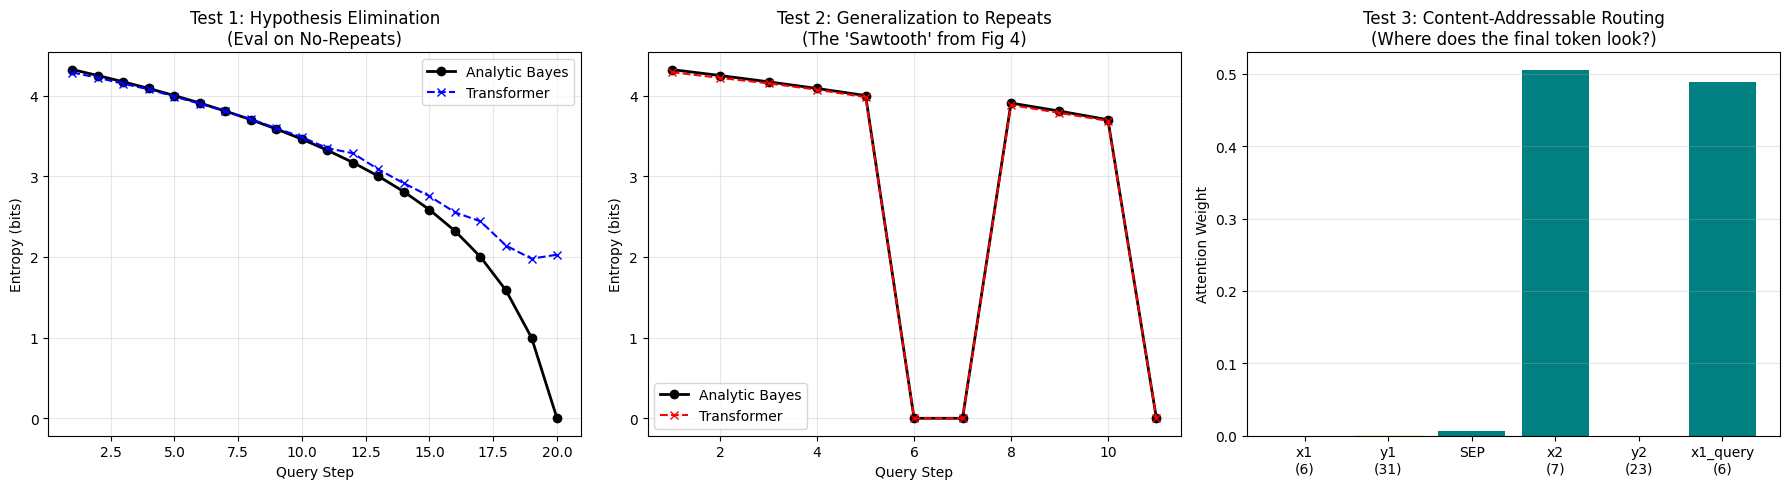

In [1]:
%matplotlib inline

import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt
from tqdm import tqdm

# ==========================================
# 1. Configuration & Hyperparameters
# ==========================================
V = 20                   
SEP_TOKEN = 0            
VOCAB_SIZE = 1 + 2 * V   

# The bare-metal minimum width
D_MODEL = 32
N_HEADS = 2
D_FFN = 64

# The mathematical limit for associative recall
N_LAYERS = 2

BATCH_SIZE = 512
LR = 3e-3
WEIGHT_DECAY = 0.01
GRAD_CLIP = 1.0
TRAIN_STEPS = 8000 

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

# ==========================================
# 2. Data Generation (Mixed for Both Primitives)
# ==========================================
def generate_batch(batch_size, seq_len=20, mode='mixed'):
    """
    BLAZING FAST Vectorized Data Generation.
    All tensors are generated directly on the target device.
    No CPU->GPU transfers during the training loop.
    """
    # 1. Create a random lookup table for the batch directly on device.
    Y_vals = torch.rand(batch_size, V, device=device).argsort(dim=1) + 21
    
    # Pad the lookup table so index corresponds to X value (1..20)
    lookup = torch.zeros(batch_size, V + 1, dtype=torch.long, device=device)
    lookup[:, 1:] = Y_vals
    
    # 2. Sample X queries
    if mode == 'mixed':
        X_sampled = torch.randint(1, V + 1, (batch_size, seq_len), device=device)
    else: # no_repeats
        X_sampled = torch.rand(batch_size, V, device=device).argsort(dim=1)[:, :seq_len] + 1
        
    # 3. Vectorized lookup: Get Y answers simultaneously for the whole batch
    Y_sampled = torch.gather(lookup, 1, X_sampled)
    
    # 4. Interleave [X, Y, SEP] using stride slicing
    seq = torch.zeros(batch_size, seq_len * 3, dtype=torch.long, device=device)
    seq[:, 0::3] = X_sampled
    seq[:, 1::3] = Y_sampled
    seq[:, 2::3] = SEP_TOKEN
    
    inputs = seq[:, :-1]
    targets = seq[:, 1:]
    
    # Mask
    mask = torch.zeros(seq_len * 3 - 1, dtype=torch.bool, device=device)
    mask[0::3] = True
    mask = mask.unsqueeze(0).expand(batch_size, -1)
    
    return inputs, targets, mask

def get_analytic_entropy(query_list):
    """Calculates true Bayesian entropy, dropping to 0 if a token is repeated."""
    seen = set()
    entropies = []
    for x in query_list:
        if x in seen:
            entropies.append(0.0)
        else:
            entropies.append(math.log2(max(1, V - len(seen))))
            seen.add(x)
    return entropies

# ==========================================
# 3. Model Architecture (With Attention Hook)
# ==========================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        self.pos_emb = nn.Embedding(max_len, d_model)
        # Pre-compute positions rather than calculating every forward pass
        self.register_buffer('positions', torch.arange(max_len).unsqueeze(0))
        
    def forward(self, x):
        return x + self.pos_emb(self.positions[:, :x.size(1)])

class TransformerBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.ln1 = nn.LayerNorm(D_MODEL)
        self.attn = nn.MultiheadAttention(D_MODEL, N_HEADS, batch_first=True)
        self.ln2 = nn.LayerNorm(D_MODEL)
        self.ffn = nn.Sequential(nn.Linear(D_MODEL, D_FFN), nn.GELU(), nn.Linear(D_FFN, D_MODEL))
        
    def forward(self, x, mask, need_weights=False):
        # Setting need_weights=False unlocks FlashAttention / avoids slow materialization
        attn_out, attn_weights = self.attn(
            self.ln1(x), self.ln1(x), self.ln1(x), 
            attn_mask=mask, 
            need_weights=need_weights, 
            average_attn_weights=need_weights
        )
        x = x + attn_out
        x = x + self.ffn(self.ln2(x))
        return x, attn_weights

class BijectionTransformer(nn.Module):
    def __init__(self, max_len=100):
        super().__init__()
        self.embed = nn.Embedding(VOCAB_SIZE, D_MODEL)
        self.pos_enc = PositionalEncoding(D_MODEL, max_len)
        self.layers = nn.ModuleList([TransformerBlock() for _ in range(N_LAYERS)])
        self.proj = nn.Linear(D_MODEL, VOCAB_SIZE)
        
        # Pre-compute causal mask to prevent generating it every single batch
        causal_mask = nn.Transformer.generate_square_subsequent_mask(max_len)
        self.register_buffer('causal_mask', causal_mask)
        
    def forward(self, x, return_attention=False):
        x = self.embed(x)
        x = self.pos_enc(x)
        
        # Instant dynamic slicing of the pre-computed mask
        mask = self.causal_mask[:x.size(1), :x.size(1)]
        
        attentions = []
        for layer in self.layers:
            x, attn_weights = layer(x, mask, need_weights=return_attention)
            if return_attention:
                attentions.append(attn_weights)
            
        logits = self.proj(x)
        if return_attention:
            return logits, attentions
        return logits

# ==========================================
# 4. Training Loop
# ==========================================
print("Initializing fresh model...")
model = BijectionTransformer().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

model.train()
print(f"Training on {device} for {TRAIN_STEPS} steps with MIXED data...")
pbar = tqdm(range(TRAIN_STEPS))
for step in pbar:
    inputs, targets, mask = generate_batch(BATCH_SIZE, seq_len=20, mode='mixed')
    
    logits = model(inputs)
    loss = F.cross_entropy(logits[mask], targets[mask])
    
    # set_to_none=True is slightly faster than zeroing memory matrices out
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
    optimizer.step()
    
    if step % 100 == 0:
        pbar.set_description(f"Loss: {loss.item():.4f}")

# ==========================================
# 5. Corrected Evaluation Suite
# ==========================================
model.eval()
fig = plt.figure(figsize=(18, 5))

# ---------------------------------------------------------
# TEST 1: Pure Hypothesis Elimination (Staircase)
# ---------------------------------------------------------
with torch.no_grad():
    inputs, targets, mask = generate_batch(1000, seq_len=20, mode='no_repeats')
    logits = model(inputs)
    pred_logits = logits[:, 0::3, :]
    
    dist = torch.distributions.Categorical(probs=F.softmax(pred_logits, dim=-1))
    model_entropy = (dist.entropy() / math.log(2)).mean(dim=0).cpu().tolist()
    analytic_entropy = get_analytic_entropy(list(range(1, 21)))
    
    ax1 = fig.add_subplot(1, 3, 1)
    ax1.plot(range(1, 21), analytic_entropy, 'o-', color='black', label="Analytic Bayes", lw=2)
    ax1.plot(range(1, 21), model_entropy, 'x--', color='blue', label="Transformer")
    ax1.set_title("Test 1: Hypothesis Elimination\n(Eval on No-Repeats)")
    ax1.set_ylabel("Entropy (bits)"); ax1.set_xlabel("Query Step")
    ax1.legend(); ax1.grid(True, alpha=0.3)

# ---------------------------------------------------------
# TEST 2: Random-Access Binding (The Sawtooth)
# ---------------------------------------------------------
with torch.no_grad():
    x_base = torch.randperm(V) + 1
    y_base = torch.randperm(V) + 21
    # Create sequence with distinct repeats: Step 6 and 7 are repeats. Step 11 is a repeat.
    query_indices = [0, 1, 2, 3, 4, 2, 0, 5, 6, 7, 3] 
    
    seq = []
    for idx in query_indices:
        seq.extend([x_base[idx].item(), y_base[idx].item(), SEP_TOKEN])
        
    inputs_sw = torch.tensor([seq[:-1]], dtype=torch.long).to(device)
    logits_sw = model(inputs_sw)
    
    dist_sw = torch.distributions.Categorical(probs=F.softmax(logits_sw[:, 0::3, :], dim=-1))
    sawtooth_entropy = (dist_sw.entropy() / math.log(2)).squeeze(0).cpu().tolist()
    analytic_sawtooth = get_analytic_entropy([x_base[i].item() for i in query_indices])
    
    ax2 = fig.add_subplot(1, 3, 2)
    steps = list(range(1, len(query_indices) + 1))
    ax2.plot(steps, analytic_sawtooth, 'o-', color='black', label="Analytic Bayes", lw=2)
    ax2.plot(steps, sawtooth_entropy, 'x--', color='red', label="Transformer")
    ax2.set_title("Test 2: Generalization to Repeats\n(The 'Sawtooth' from Fig 4)")
    ax2.set_ylabel("Entropy (bits)"); ax2.set_xlabel("Query Step")
    ax2.legend(); ax2.grid(True, alpha=0.3)

# ---------------------------------------------------------
# TEST 3: Mechanistic Attention Visualization
# ---------------------------------------------------------
with torch.no_grad():
    # Sequence: [x1, y1, SEP, x2, y2, SEP, x1(repeat)]
    seq_attn = [x_base[0].item(), y_base[0].item(), SEP_TOKEN, 
                x_base[1].item(), y_base[1].item(), SEP_TOKEN, 
                x_base[0].item()]
    
    inputs_attn = torch.tensor([seq_attn], dtype=torch.long).to(device)
    _, attentions = model(inputs_attn, return_attention=True)
    
    # Get final layer attention weights for the last token predicting 'y'
    final_attn = attentions[-1].squeeze(0).cpu().numpy()
    last_token_attn = final_attn[-1, :] 
    
    ax3 = fig.add_subplot(1, 3, 3)
    labels = [f"x1\n({seq_attn[0]})", f"y1\n({seq_attn[1]})", "SEP", 
              f"x2\n({seq_attn[3]})", f"y2\n({seq_attn[4]})", "SEP", f"x1_query\n({seq_attn[6]})"]
              
    bars = ax3.bar(labels, last_token_attn, color='teal')
    bars[1].set_color('orange') # Highlight the target answer (y1)
    
    ax3.set_title("Test 3: Content-Addressable Routing\n(Where does the final token look?)")
    ax3.set_ylabel("Attention Weight")
    ax3.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()